In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))  # permite importar src

from src.legacy_cbms26.download import MITBIHDownloader

downloader = MITBIHDownloader()
manifest = downloader.download("data/raw/mitdb")

print("\nResumo:")
for k, v in manifest.items():
    if isinstance(v, list):
        print(f"{k}: {len(v)} itens")
    else:
        print(f"{k}: {v}")

Dataset already exists in data/raw/mitdb. Use overwrite=True to replace it.

Resumo:
dataset_name: MIT-BIH Arrythmia Database
dataset_id: mitdb
source_url: https://www.physionet.org/content/mitdb/1.0.0/
version: 1.0.0
n_records: 48
record_names: 48 itens
download_date: 2025-11-13T15:01:12.547533
sampling_rate: 360
channels: 2
description: 2 itens


In [2]:
# Cria estrutura base se não existir
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

print("Estrutura de dados inicial criada.")

Estrutura de dados inicial criada.


In [3]:
# Mostra alguns arquivos
records_dir = "data/raw/mitdb/records"
files = os.listdir(records_dir)

print(f"Total files: {len(files)}")
print("Some samples:")
print(sorted(files)[:10])

Total files: 144
Some samples:
['100.atr', '100.dat', '100.hea', '101.atr', '101.dat', '101.hea', '102.atr', '102.dat', '102.hea', '103.atr']


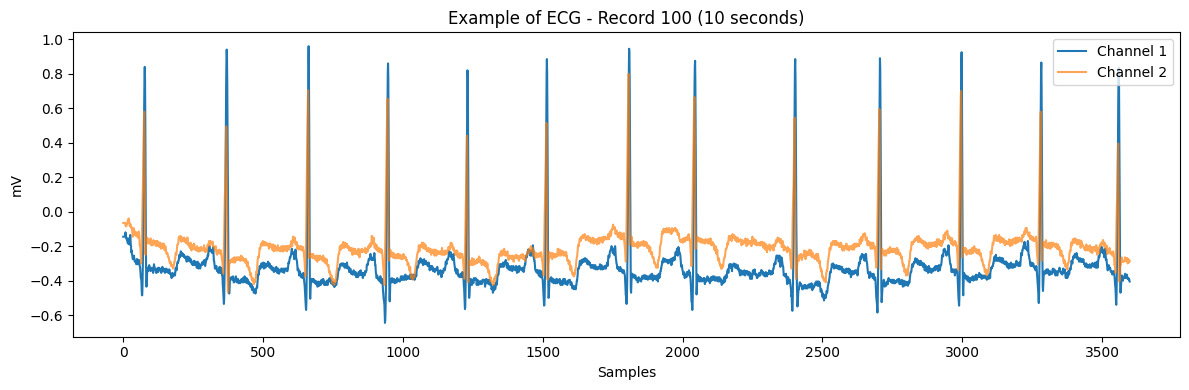

In [4]:
import wfdb
import matplotlib.pyplot as plt

record_path = os.path.join(records_dir, "100")
record = wfdb.rdrecord(record_path)

# Plota os dois canais de ECG (10 segundos)
fs = 360
start, end = 0, 10 * fs

plt.figure(figsize=(12, 4))
plt.plot(record.p_signal[start:end, 0], label="Channel 1")
plt.plot(record.p_signal[start:end, 1], label="Channel 2", alpha=0.7)
plt.title("Example of ECG - Record 100 (10 seconds)")
plt.xlabel("Samples")
plt.ylabel("mV")
plt.legend()
plt.tight_layout()
plt.show()